/Users/pablom.perez/miniconda3/envs/sci-py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/pablom.perez/miniconda3/envs/sci-py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/var/folders/qq/_c3h3m7x0cj6f8qprnj5kyjw0000gq/T/ipykernel_66913/589620555.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


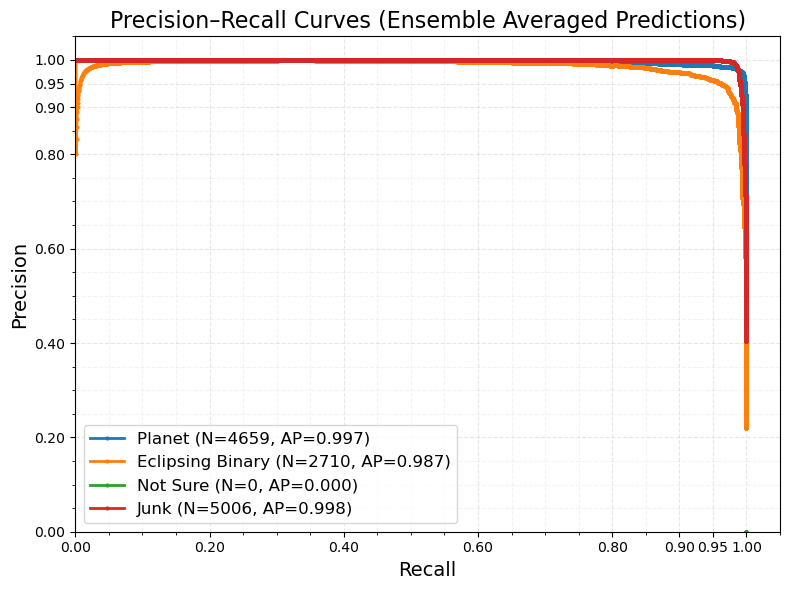


Loaded 12375 predictions
Columns: ['astro_id', 'avg_disp_p', 'avg_disp_e', 'avg_disp_n', 'avg_disp_j', 'disp_p', 'disp_e', 'disp_n', 'disp_j']


In [1]:
# Notebook cell: Load averaged predictions and create PR curves
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Load the averaged predictions
csv_path = '/Users/pablom.perez/Desktop/ensemble_predictions_averaged.csv'
df = pd.read_csv(csv_path)

# Define label columns
label_cols = ['disp_p', 'disp_e', 'disp_n', 'disp_j']
pred_cols = ['avg_disp_p', 'avg_disp_e', 'avg_disp_n', 'avg_disp_j']
label_names = ['Planet', 'Eclipsing Binary', 'Not Sure', 'Junk']

# Create PR curves for each class
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

for i, (label_col, pred_col, name) in enumerate(zip(label_cols, pred_cols, label_names)):
    # Get true labels and predictions
    y_true = df[label_col].values
    y_score = df[pred_col].values

    # Remove NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_score))
    y_true = y_true[mask]
    y_score = y_score[mask]

    if len(y_true) == 0:
        print(f"Skipping {name}: No valid data")
        continue

    # Compute PR curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    # Count positive samples
    n_positives = int(y_true.sum())

    # Plot
    lbl = f"{name} (N={n_positives}, AP={ap:.3f})"
    ax.plot(recall[:-1], precision[:-1], lw=2, label=lbl, marker='o', markersize=2)

ax.set_xlabel("Recall", fontsize=14)
ax.set_ylabel("Precision", fontsize=14)
ax.set_title("Precision–Recall Curves (Ensemble Averaged Predictions)", fontsize=16)

# Set specific tick marks including 0.9 and 0.95
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0])

ax.grid(True, which="both", linestyle="--", alpha=0.3)
ax.minorticks_on()
ax.grid(True, which="minor", alpha=0.15)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left", fontsize=12, framealpha=0.8)

plt.tight_layout()
plt.show()

print(f"\nLoaded {len(df)} predictions")
print(f"Columns: {list(df.columns)}")
